In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.varmax import VARMAX
import statsmodels.api as sm
from tqdm.notebook import tqdm
from itertools import product
from typing import Union

In [145]:
macro_data = sm.datasets.macrodata.load_pandas().data

In [146]:
macro_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


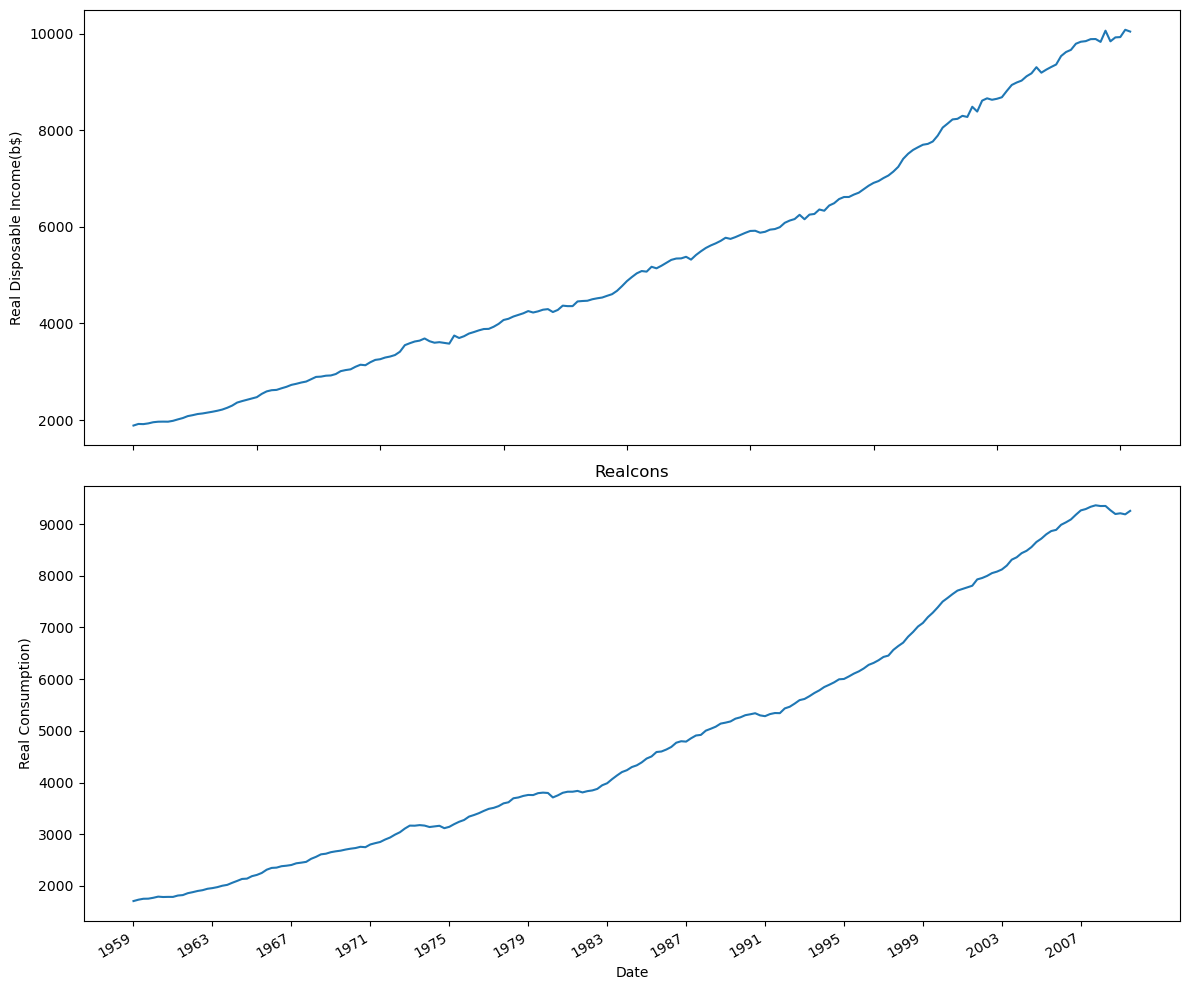

In [147]:
fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12,10))

ax1.plot(macro_data['realdpi'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Real Disposable Income(b$)')
plt.title('Realdpi')

ax2.plot(macro_data['realcons'])
ax2.set_xlabel('Date')
ax2.set_ylabel('Real Consumption)')
plt.title('Realcons')

plt.xticks(
    np.arange(0,208,16),
    np.arange(1959,2010,4)
)

fig.autofmt_xdate()
plt.tight_layout()


In [148]:
##Testing for stationnarity
def adf_test(serie):
    test = adfuller(serie)

    print(f"stat: {test[0]}")
    print(f"p-value: {test[1]}")

    return 'not stationary' if test[1] > 0.05 else 'stationary'

In [149]:
adf_test(macro_data['realdpi'])

stat: 2.9860253519546864
p-value: 1.0


'not stationary'

In [150]:
adf_test(macro_data['realcons'])

stat: 1.5499123380509656
p-value: 0.9976992503412904


'not stationary'

In [151]:
diff_cons = np.diff(macro_data['realcons'])
diff_dpi = np.diff(macro_data['realdpi'])

In [152]:
adf_test(diff_cons)

stat: -4.204306080845247
p-value: 0.0006479282158627571


'stationary'

In [153]:
adf_test(diff_dpi)

stat: -8.864893340673003
p-value: 1.4493606159108354e-14


'stationary'

In [154]:
def OptimizedVAR(endog:Union[pd.Series, list]) -> pd.DataFrame:
    results = []
    for i in tqdm(range(15)):
        try:
            model = VARMAX(endog, order=(i,0)).fit(disp=False) 
        except:
            continue
        aic = model.aic
        results.append([i,aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['p', 'AIC']
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df


In [155]:
endog = macro_data[['realdpi', 'realcons']]
endog

,realdpi,realcons
0,1886.9,1707.4
1,1919.7,1733.7
2,1916.4,1751.8
3,1931.3,1753.7
4,1955.5,1770.5
...,...,...
198,9838.3,9267.7
199,9920.4,9195.3
200,9926.4,9209.2
201,10077.5,9189.0


In [156]:
endog_diff = macro_data[['realdpi', 'realcons']].diff()[1:]

In [157]:
train = endog_diff[:162]
test = endog_diff[162:]

result = OptimizedVAR(train)

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

In [158]:
result

,p,AIC
0,3,3123.070081
1,5,3123.708523
2,6,3126.855595
3,4,3129.194041
4,2,3130.091668
5,7,3133.398310
6,1,3134.333343
7,8,3137.149016
8,9,3140.367182
9,10,3147.838628


In [159]:
granger_1 = grangercausalitytests(macro_data[['realdpi', 'realcons']].diff()[1:], [3])
print(granger_1)
print('\n')
granger_2 = grangercausalitytests(macro_data[['realcons', 'realdpi']].diff()[1:], [3])
print(granger_2)


Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
{3: ({'ssr_ftest': (9.236302935003351, 9.77165988100445e-06, 192.0, 3), 'ssr_chi2test': (28.719129438526046, 2.5653542414504216e-06, 3), 'lrtest': (26.826823124426937, 6.400614700874191e-06, 3), 'params_ftest': (9.236302935003325, 9.771659881004797e-06, 192.0, 3.0)}, [<statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x7078edd359a0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x7078edf1fd10>, array([[0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.]])])}



Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 

In [160]:
model = VARMAX(train, order=(3,0))
result_model = model.fit(disp=False)

In [161]:
result_model.summary()

Dep. Variable:,"['realdpi', 'realcons']",No. Observations:,162
Model:,VAR(3),Log Likelihood,-1544.535
,+ intercept,AIC,3123.070
Date:,"Mon, 31 Aug 2026",BIC,3175.559
Time:,21:09:18,HQIC,3144.381
Sample:,0,,
,- 162,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.01, 0.03",Jarque-Bera (JB):,"43.86, 4.35"
Prob(Q):,"0.91, 0.87",Prob(JB):,"0.00, 0.11"
Heteroskedasticity (H):,"4.44, 3.59",Skew:,"0.14, -0.21"


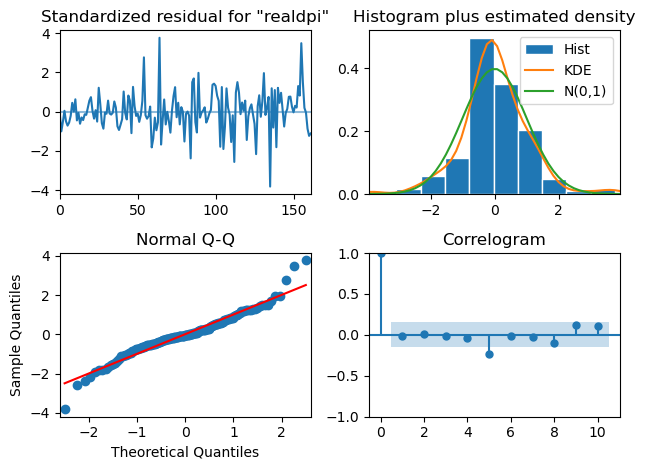

In [162]:
result_model.plot_diagnostics(variable=0)
plt.tight_layout()

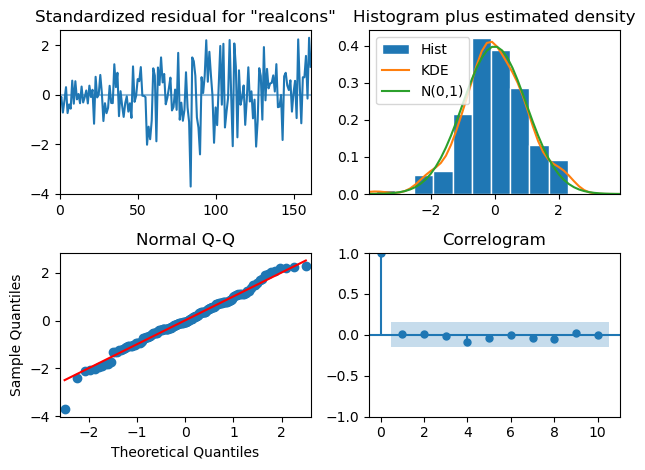

In [163]:
result_model.plot_diagnostics(variable=1)
plt.tight_layout()

In [164]:
pvalue = acorr_ljungbox(result_model.resid['realdpi'])
print(pvalue)

      lb_stat  lb_pvalue
1    0.011632   0.914114
2    0.029390   0.985413
3    0.075815   0.994573
4    0.377928   0.984244
5    9.142568   0.103511
6    9.165403   0.164487
7    9.270154   0.233838
8   10.811607   0.212604
9   13.318134   0.148731
10  15.287396   0.121930


In [165]:
pvalue = acorr_ljungbox(result_model.resid['realcons'])
print(pvalue)

     lb_stat  lb_pvalue
1   0.023885   0.877177
2   0.068689   0.966239
3   0.068766   0.995302
4   0.235694   0.993578
5   0.377743   0.995921
6   0.787320   0.992409
7   1.015265   0.994579
8   2.150430   0.976049
9   2.437116   0.982527
10  2.442781   0.991684


In [178]:
def rolling_forecast(df:pd.DataFrame, train_len:int, window:int, horizon:int, method:str) -> list:
    results = []
    total_len = train_len + horizon

    if method == 'VAR':
        realdpi_pred = []
        realcons_pred = []

        for i in range(train_len, total_len, window):
            model = VARMAX(df[:i], order=(3,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)

            oos_dpi = predictions.predicted_mean.iloc[-window:]['realdpi']
            oos_cons = predictions.predicted_mean.iloc[-window:]['realcons']

            realdpi_pred.extend(oos_dpi)
            realcons_pred.extend(oos_cons)
            
        return realdpi_pred, realcons_pred

    elif method == 'last':
        last_pred_dpi = []
        last_pred_cons = []

        for i in range(train_len, total_len, window):
            last_dpi = df[:i].iloc[-1]['realdpi']
            last_cons = df[:i].iloc[-1]['realcons']

            last_pred_dpi.extend(last_dpi for _ in range(window))
            last_pred_cons.extend(last_cons for _ in range(window))
        return last_pred_dpi , last_pred_cons

In [179]:
TRAIN_LEN = len(train)
HORIZON = len(test)

WINDOW = 4

realdpi_preds_VAR, realcons_preds_VAR = rolling_forecast(endog_diff, TRAIN_LEN, WINDOW, HORIZON, 'VAR')

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


since we used diff values, we must undiff them

In [180]:
test = endog[163:]

test['DPI_VAR'] = pd.Series()
test['DPI_VAR'] = endog.iloc[162]['realdpi'] + np.cumsum(realdpi_preds_VAR)

test['CONS_VAR'] = pd.Series()
test['CONS_VAR'] = endog.iloc[162]['realcons'] + np.cumsum(realcons_preds_VAR)

/tmp/ipykernel_326253/106101286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['DPI_VAR'] = pd.Series()
/tmp/ipykernel_326253/106101286.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['DPI_VAR'] = endog.iloc[162]['realdpi'] + np.cumsum(realdpi_preds_VAR)
/tmp/ipykernel_326253/106101286.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [181]:
realdpi_preds_last, realcons_preds_last = rolling_forecast(endog, TRAIN_LEN, WINDOW, HORIZON, 'last')
test['last_dpi'] = realdpi_preds_last
test['last_cons'] = realcons_preds_last

/tmp/ipykernel_326253/3165559116.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['last_dpi'] = realdpi_preds_last
/tmp/ipykernel_326253/3165559116.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['last_cons'] = realcons_preds_last


In [182]:
test

,realdpi,realcons,DPI_VAR,CONS_VAR,last_dpi,last_cons
163,7887.7,7389.2,7829.222835,7354.323771,7716.0,7199.9
164,8053.4,7501.3,7897.185920,7430.253345,7716.0,7199.9
165,8135.9,7571.8,7960.559203,7496.626486,7716.0,7199.9
166,8222.3,7645.9,8014.751465,7556.610897,7716.0,7199.9
167,8234.6,7713.5,8080.701694,7630.998981,8135.9,7571.8
168,8296.5,7744.3,8142.395901,7692.852127,8135.9,7571.8
169,8273.7,7773.5,8200.131349,7753.877020,8135.9,7571.8
170,8484.5,7807.7,8259.375588,7812.551257,8135.9,7571.8
171,8385.5,7930.0,8264.399558,7864.651847,8273.7,7773.5
172,8611.6,7957.3,8320.871900,7895.076582,8273.7,7773.5


In [183]:
mape_dpi_var = mean_absolute_percentage_error(test['realdpi'], test['DPI_VAR'])
mape_cons_var = mean_absolute_percentage_error(test['realcons'], test['CONS_VAR'])

In [184]:
mape_last_dpi = mean_absolute_percentage_error(test['realdpi'], test['last_dpi'])
mape_last_cons = mean_absolute_percentage_error(test['realcons'], test['last_cons'])

In [185]:
print(mape_dpi_var, mape_last_dpi)

0.03138388791587676 0.022626174331286664


In [186]:
print(mape_cons_var, mape_last_cons)

0.01771148189334109 0.024593150211915073


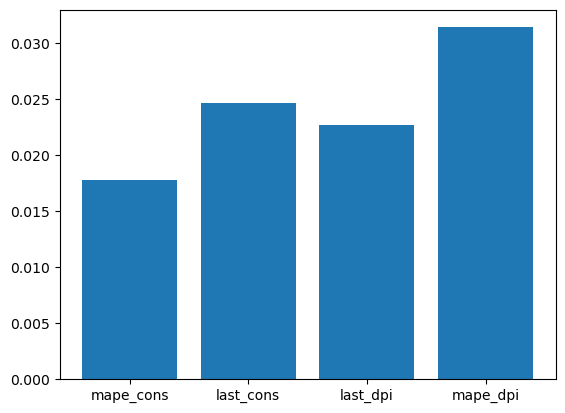

In [191]:
fig, ax = plt.subplots()

names = ['mape_cons', 'last_cons', 'last_dpi', 'mape_dpi' ]
values = [mape_cons, mape_last_cons, mape_last_dpi, mape_dpi]

ax.bar(names, values)
plt.show()

In [175]:
test.columns

Index(['realdpi', 'realcons', 'DPI_VAR', 'CONS_VAR', 'last_dpi', 'last_cons'], dtype='object')

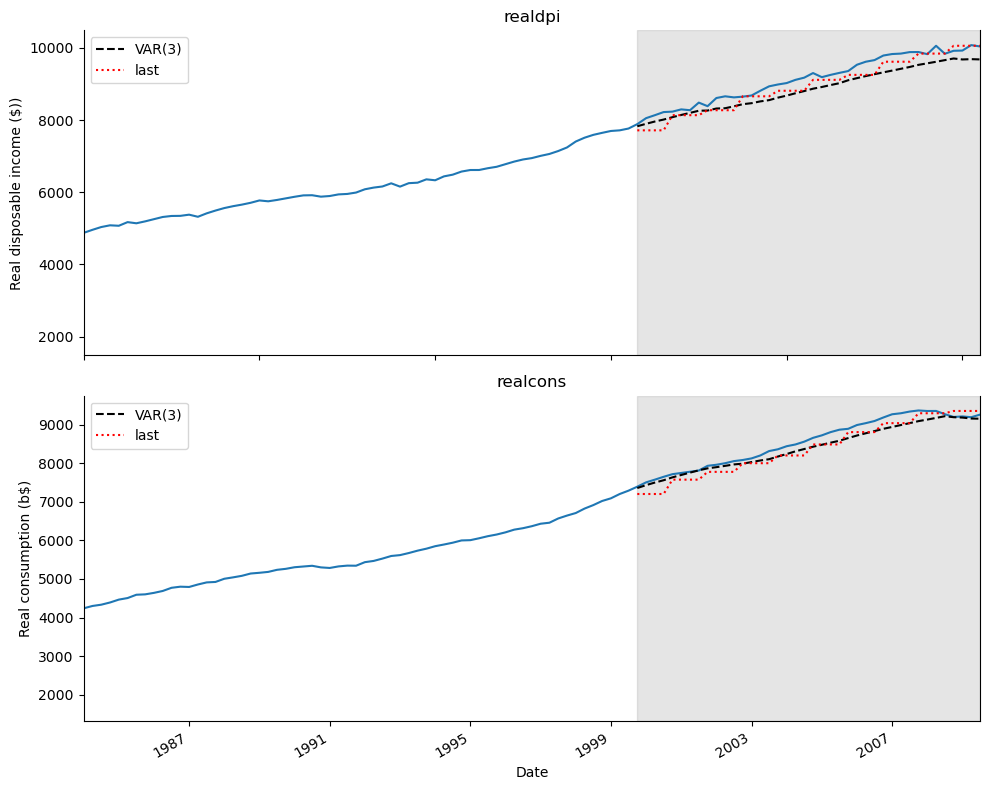

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

ax1.plot(macro_data['realdpi'])
ax1.plot(test['DPI_VAR'], 'k--', label='VAR(3)')
ax1.plot(test['last_dpi'], 'r:', label='last')
ax1.set_xlabel('Date')
ax1.set_ylabel('Real disposable income ($))')
ax1.set_title('realdpi')
ax1.spines['top'].set_alpha(0)
ax1.axvspan(163, 202, color='#808080', alpha=0.2)
ax1.set_xlim(100, 202)
ax1.legend(loc=2)

ax2.plot(macro_data['realcons'])
ax2.plot(test['CONS_VAR'], 'k--', label='VAR(3)')
ax2.plot(test['last_cons'], 'r:', label='last')
ax2.set_xlabel('Date')
ax2.set_ylabel('Real consumption (b$)')
ax2.set_title('realcons')
ax2.spines['top'].set_alpha(0)
ax2.axvspan(163, 202, color='#808080', alpha=0.2)
ax2.set_xlim(100, 202)
ax2.legend(loc=2)

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))
plt.xlim(100, 202)

fig.autofmt_xdate()
plt.tight_layout()